In [2]:
import pandas as pd
import requests as req
import numpy
import matplotlib.pyplot as plt
import statistics
import seaborn as sns
from scipy.stats import kurtosis
from azure.storage.blob import BlobClient, BlobType, BlobServiceClient
from pathlib import Path
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [10]:
from_date = input("enter from year and month hypen separated:")
to_date = input("enter to year and month hypen separated:")
country_code = input("enter three letter country code in capital")

power_generation_url = f"https://api.ember-energy.org/v1/electricity-generation/monthly?entity_code={country_code}&is_aggregate_entity=false&start_date={from_date}&end_date={to_date}&is_aggregate_series=false&include_all_dates_value_range=false&api_key="
json_repsonse = req.get(power_generation_url)
print(json_repsonse.json()['data'])
power_df = pd.DataFrame(json_repsonse.json()['data'])
# power_df['updated_on'] = pd.to_datetime(power_df['updated_on'], unit='ms')
print(power_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])
power_source = input("Enter source of power: ")

[{'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Bioenergy', 'is_aggregate_series': False, 'generation_twh': 2.18, 'share_of_generation_pct': 1.91}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Coal', 'is_aggregate_series': False, 'generation_twh': 87.4, 'share_of_generation_pct': 76.75}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Gas', 'is_aggregate_series': False, 'generation_twh': 3.39, 'share_of_generation_pct': 2.98}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Hydro', 'is_aggregate_series': False, 'generation_twh': 9.23, 'share_of_generation_pct': 8.1}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2020-01-01', 'series': 'Net imports', 'is_aggregate_series': False, 'generation_twh': -0.46, 'share_of_generation

In [11]:
power_source_df = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0)]
print(power_source_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])

    entity entity_code        date series  generation_twh
8    India         IND  2020-01-01  Solar            4.89
18   India         IND  2020-02-01  Solar            5.40
28   India         IND  2020-03-01  Solar            5.97
38   India         IND  2020-04-01  Solar            5.71
48   India         IND  2020-05-01  Solar            5.99
..     ...         ...         ...    ...             ...
678  India         IND  2025-08-01  Solar           16.24
688  India         IND  2025-09-01  Solar           17.82
698  India         IND  2025-10-01  Solar           17.25
708  India         IND  2025-11-01  Solar           17.46
718  India         IND  2025-12-01  Solar           19.46

[72 rows x 5 columns]


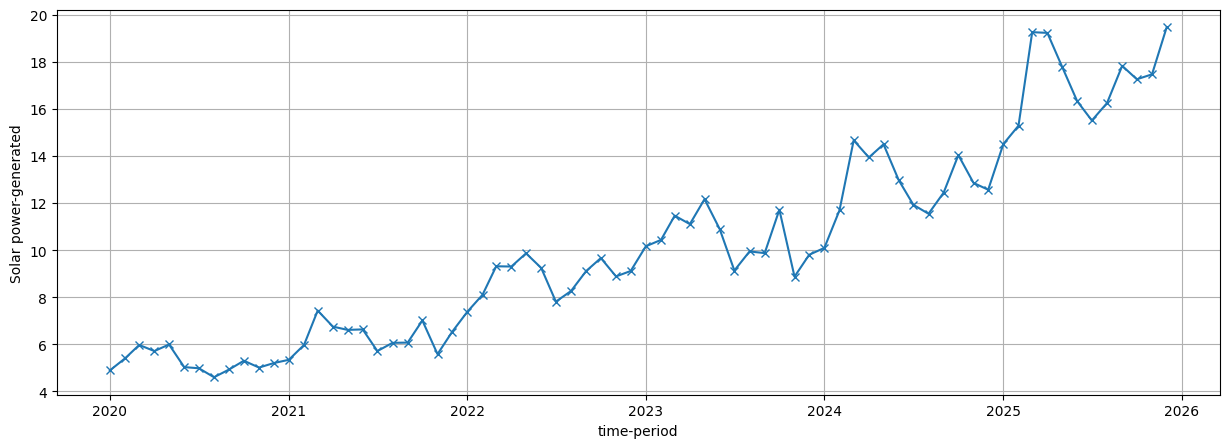

In [12]:
power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(15)
power_gen_fig.set_figheight(5)

x_axis_points = numpy.array(pd.DatetimeIndex(power_source_df['date']))
y_axis_points = numpy.array(power_source_df['generation_twh'])

plt.xlabel('time-period')
plt.ylabel(power_source+' power-generated')

# plt.bar(x_axis_points, y_axis_points, color="green")
plt.plot(x_axis_points, y_axis_points, marker = 'x')
plt.grid()


In [13]:
year_set = set()
for row in power_source_df.iterrows():
    year_set.update(pd.DatetimeIndex(power_source_df['date']).year)

yr_mm_dict = dict()

for i in year_set:
    mm_ls = list() 
    for date_val in power_source_df['date']:        
        if(pd.Timestamp(date_val).year == i):            
            mm_ls.append(pd.Timestamp(date_val).month)        
    yr_mm_dict[i] = mm_ls

print(yr_mm_dict)
print(year_set)
power_df

# print(year_set)
# print(power_source_df.groupby([pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].sum())
    

{2020: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2021: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2022: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2023: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2024: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2025: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
{2020, 2021, 2022, 2023, 2024, 2025}


,entity,entity_code,is_aggregate_entity,date,series,is_aggregate_series,generation_twh,share_of_generation_pct
0,India,IND,False,2020-01-01,Bioenergy,False,2.18,1.91
1,India,IND,False,2020-01-01,Coal,False,87.40,76.75
2,India,IND,False,2020-01-01,Gas,False,3.39,2.98
3,India,IND,False,2020-01-01,Hydro,False,9.23,8.10
4,India,IND,False,2020-01-01,Net imports,False,-0.46,-0.40
...,...,...,...,...,...,...,...,...
715,India,IND,False,2025-12-01,Nuclear,False,4.22,2.74
716,India,IND,False,2025-12-01,Other fossil,False,0.04,0.03
717,India,IND,False,2025-12-01,Other renewables,False,0.25,0.16
718,India,IND,False,2025-12-01,Solar,False,19.46,12.62


           date series  generation_twh
8    2020-01-01  Solar            4.89
18   2020-02-01  Solar            5.40
28   2020-03-01  Solar            5.97
38   2020-04-01  Solar            5.71
48   2020-05-01  Solar            5.99
58   2020-06-01  Solar            5.03
68   2020-07-01  Solar            4.98
78   2020-08-01  Solar            4.60
88   2020-09-01  Solar            4.93
98   2020-10-01  Solar            5.30
108  2020-11-01  Solar            5.01
118  2020-12-01  Solar            5.20
           date series  generation_twh
128  2021-01-01  Solar            5.34
138  2021-02-01  Solar            5.97
148  2021-03-01  Solar            7.43
158  2021-04-01  Solar            6.75
168  2021-05-01  Solar            6.61
178  2021-06-01  Solar            6.63
188  2021-07-01  Solar            5.71
198  2021-08-01  Solar            6.06
208  2021-09-01  Solar            6.07
218  2021-10-01  Solar            7.01
228  2021-11-01  Solar            5.58
238  2021-12-01  Solar   

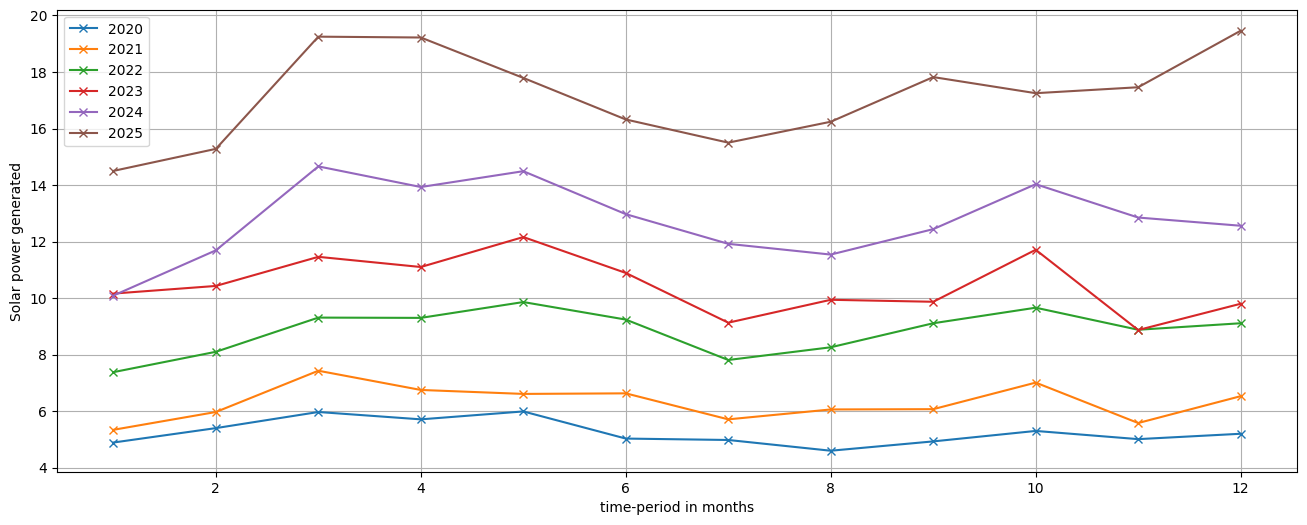

In [14]:
power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(16)
power_gen_fig.set_figheight(6)

plt.grid()

plt.xlabel("time-period in months")
plt.ylabel(power_source+ " power generated")


for yr in year_set:
    power_source_df = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == yr)]
    print(power_source_df[['date','series', 'generation_twh']])
    x_axis_points = numpy.array(pd.DatetimeIndex(power_source_df['date']).month)
    y_axis_points = numpy.array(power_source_df['generation_twh'])
    plt.plot(x_axis_points, y_axis_points, marker = 'x', label=str(yr))
    plt.legend()

Standard Deviation =  0.440917603791608
Mean =  5.2508333333333335
Variance =  0.19440833333333338
Standard Deviation =  0.6214517460972112
Mean =  6.3075
Variance =  0.3862022727272727
Standard Deviation =  0.7704131123211518
Mean =  8.835
Variance =  0.5935363636363638
Standard Deviation =  1.0219855896511192
Mean =  10.46
Variance =  1.044454545454546
Standard Deviation =  1.3566969135188285
Mean =  12.764166666666666
Variance =  1.8406265151515155
Standard Deviation =  1.6444808981081005
Mean =  17.174166666666668
Variance =  2.7043174242424244


<Figure size 1600x600 with 0 Axes>

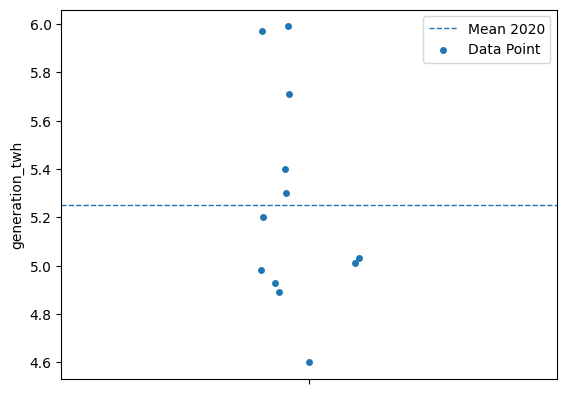

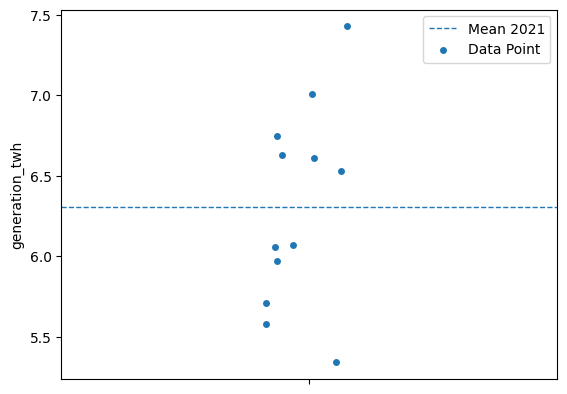

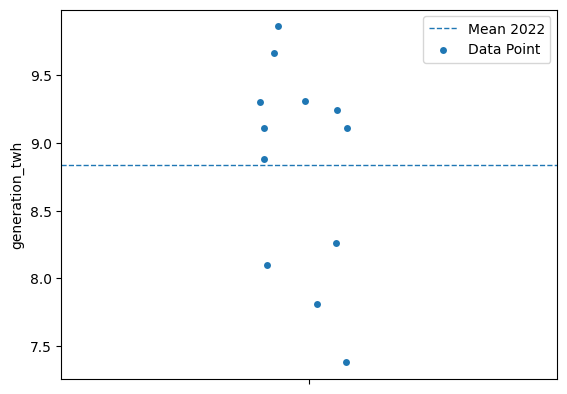

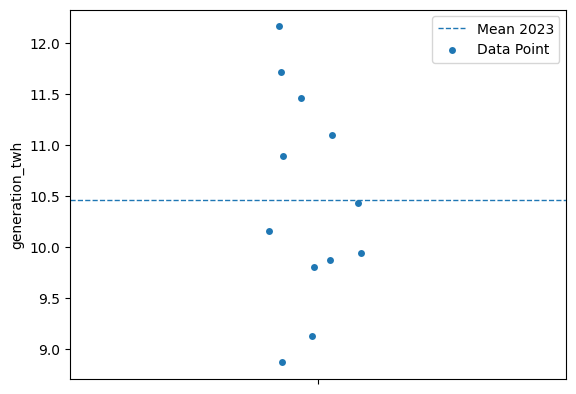

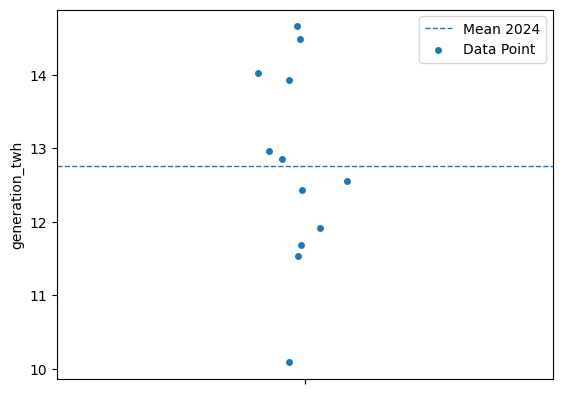

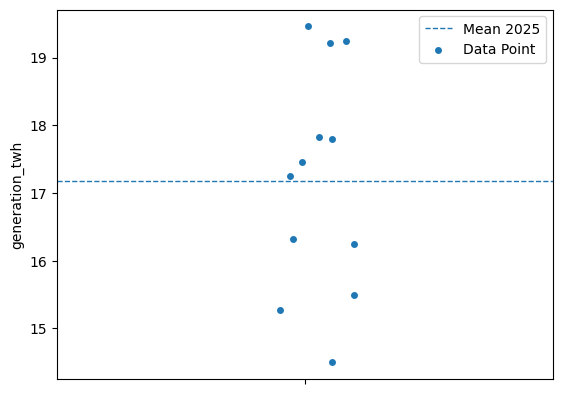

In [15]:
current_power_source = pd.DataFrame()

power_gen_fig = plt.figure()
power_gen_fig.set_figwidth(16)
power_gen_fig.set_figheight(6)

def create_plots(mn, yr):
    plt.figure()
    plt.axhline(mn, linestyle='dashed', linewidth=1, label ='Mean '+str(yr))    
    sns.stripplot(current_power_source['generation_twh'], label = "Data Point")         
    plt.legend()

for y in year_set:
    current_power_source = power_df.loc[(power_df['series'] == power_source) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == y)]
    print("Standard Deviation = ",statistics.stdev(current_power_source['generation_twh']))
    print("Mean = ",statistics.mean(current_power_source['generation_twh']))
    print("Variance = ", statistics.variance(current_power_source['generation_twh']))
    std_dev = statistics.stdev(current_power_source['generation_twh'])
    mn = statistics.mean(current_power_source['generation_twh'])
    var = statistics.variance(current_power_source['generation_twh'])
    create_plots(mn, y)   


[4.6, 4.89, 4.93, 4.98, 5.01, 5.03, 5.2, 5.3, 5.4, 5.71, 5.97, 5.99]
median =  5.115
Q1 =  4.9675
Q2 =  5.115
Q3 =  5.4775
[5.34, 5.58, 5.71, 5.97, 6.06, 6.07, 6.53, 6.61, 6.63, 6.75, 7.01, 7.43]
median =  6.300000000000001
Q1 =  5.904999999999999
Q2 =  6.300000000000001
Q3 =  6.66
[7.38, 7.81, 8.1, 8.26, 8.88, 9.11, 9.11, 9.24, 9.3, 9.31, 9.66, 9.86]
median =  9.11
Q1 =  8.219999999999999
Q2 =  9.11
Q3 =  9.3025
[8.87, 9.13, 9.8, 9.87, 9.94, 10.16, 10.43, 10.89, 11.1, 11.46, 11.71, 12.16]
median =  10.295
Q1 =  9.8525
Q2 =  10.295
Q3 =  11.19
[10.09, 11.54, 11.69, 11.92, 12.44, 12.56, 12.85, 12.97, 13.93, 14.03, 14.49, 14.66]
median =  12.705
Q1 =  11.8625
Q2 =  12.705
Q3 =  13.955
[14.5, 15.28, 15.5, 16.24, 16.32, 17.25, 17.46, 17.79, 17.82, 19.22, 19.25, 19.46]
median =  17.355
Q1 =  16.055
Q2 =  17.355
Q3 =  18.17


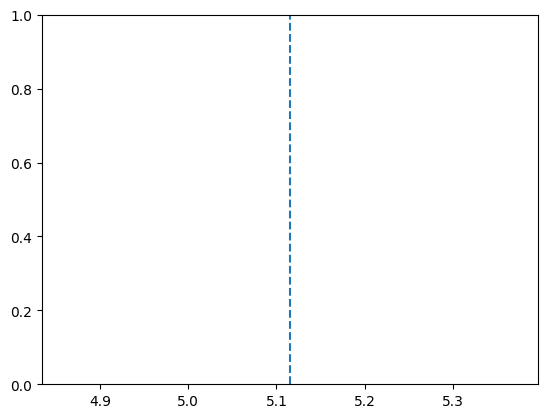

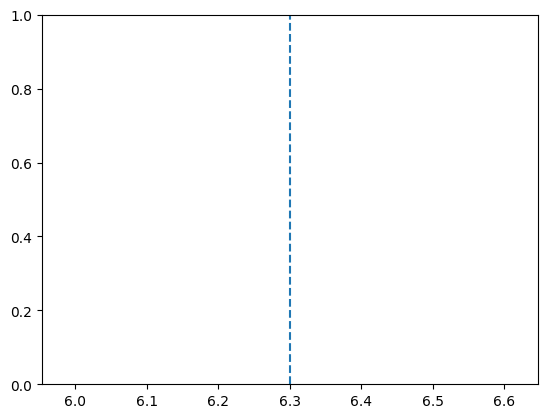

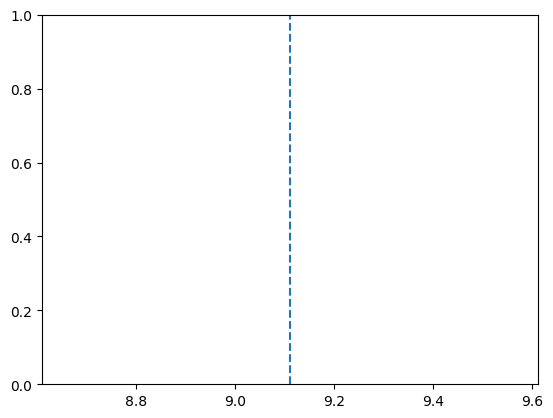

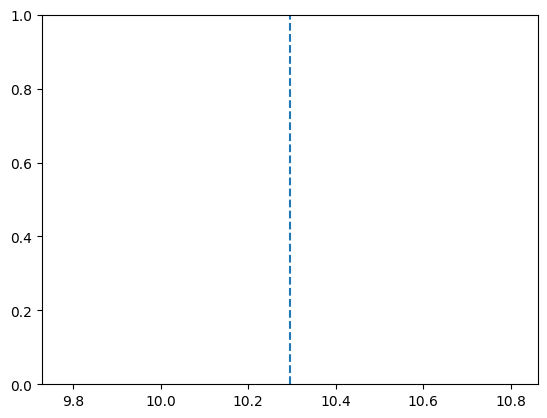

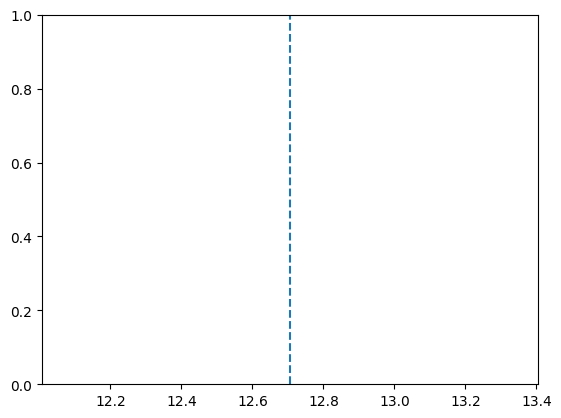

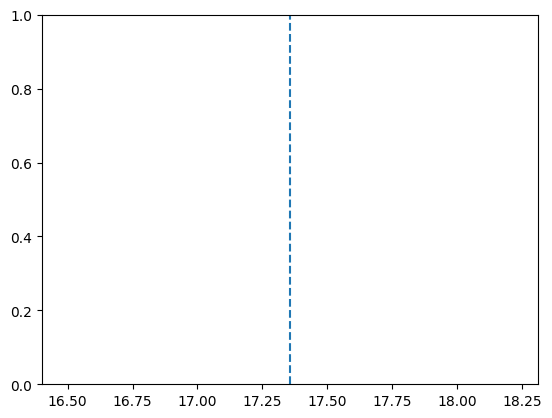

In [ ]:
# print(current_power_source)

for y in year_set:
    df = power_df.loc[(power_source == power_df['series']) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == y)]
    print(sorted(df['generation_twh']))
    med = statistics.median(sorted(df['generation_twh']))
    print("median = ", med)

    q_1 = numpy.quantile(df['generation_twh'], 0.25)
    q_2 = numpy.quantile(df['generation_twh'], 0.50)
    q_3 = numpy.quantile(df['generation_twh'], 0.75)

    print("Q1 = ", q_1)
    print("Q2 = ", q_2)
    print("Q3 = ", q_3)
    
    plt.figure()
    plt.axvline(med,linestyle="dashed")    

In [275]:
training_power_source = power_df.loc[(power_df['generation_twh'] != 0) & (power_df['series'] == power_source)]
training_power_source
energy_model = ARIMA(training_power_source['generation_twh'], order=(4,3,1))
model_fit= energy_model.fit()
print(model_fit.forecast(steps=5))

coal_data = training_power_source[training_power_source["series"] == "Coal"]
print(coal_data.tail())

841    112.023091
851    114.070863
861    118.015238
871    120.885774
881    126.951295
Name: predicted_mean, dtype: float64
    entity entity_code  is_aggregate_entity        date series  \
791  India         IND                False  2025-08-01   Coal   
801  India         IND                False  2025-09-01   Coal   
811  India         IND                False  2025-10-01   Coal   
821  India         IND                False  2025-11-01   Coal   
831  India         IND                False  2025-12-01   Coal   

     is_aggregate_series  generation_twh  share_of_generation_pct  
791                False          102.45                    62.61  
801                False           99.54                    62.72  
811                False           96.17                    66.52  
821                False           96.12                    70.47  
831                False          111.37                    72.21  


In [ ]:
file_path = "E:\\India-Power-Capacity-DE\\"

for yr in year_set:
    df = power_df.loc[(power_source == power_df['series']) & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == yr)]
    print(df[['series', 'generation_twh', 'date']])
    f = open(file_path+power_source+"_power_generated"+"_"+str(yr),'a')
    df[['series', 'generation_twh', 'date']].to_csv(file_path+power_source+"_power_generated"+"_"+str(yr), index=False)
    f.close()
    file_name = power_source+"_power_generated"+"_"+str(yr)
    conn_string = ""
    blb_service_client = BlobServiceClient.from_connection_string(conn_string)
    container_client_obj = blb_service_client.get_container_client("yearly-power-generation")
    with open(file = os.path.join("E:\\India-Power-Capacity-DE",file_name), mode="rb") as data:
        container_client_obj.upload_blob(name=file_name, data=data, overwrite=True)


    # file_upload(power_source+"_power_generated"+"_"+str(yr))



    # with open(file_path+power_source+"_power_generated"+"_"+str(yr), 'a') as f:
        # df.to_csv()



    series  generation_twh        date
1     Coal           86.37  2019-01-01
11    Coal           78.20  2019-02-01
21    Coal           91.30  2019-03-01
31    Coal           90.44  2019-04-01
41    Coal           94.37  2019-05-01
51    Coal           89.88  2019-06-01
61    Coal           83.20  2019-07-01
71    Coal           76.83  2019-08-01
81    Coal           74.60  2019-09-01
91    Coal           74.86  2019-10-01
101   Coal           75.72  2019-11-01
111   Coal           82.77  2019-12-01
    series  generation_twh        date
121   Coal           87.40  2020-01-01
131   Coal           85.62  2020-02-01
141   Coal           78.50  2020-03-01
151   Coal           61.94  2020-04-01
161   Coal           72.66  2020-05-01
171   Coal           73.06  2020-06-01
181   Coal           80.58  2020-07-01
191   Coal           74.69  2020-08-01
201   Coal           81.58  2020-09-01
211   Coal           84.89  2020-10-01
221   Coal           78.71  2020-11-01
231   Coal           87.9

2.45
2.34
1.65


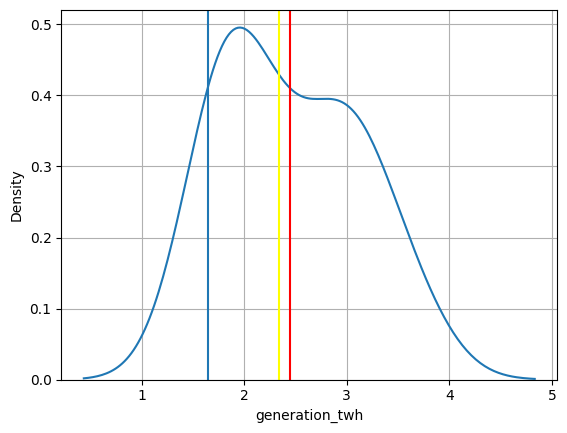

In [20]:
gas_power_generation_2023 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2023)]
# print(gas_power_generation_2023['generation_twh'])
gas_power_mean_2023 = statistics.mean(gas_power_generation_2023['generation_twh'])
gas_power_median_2023 = statistics.median(sorted(gas_power_generation_2023['generation_twh']))
gas_power_mode_2023 = statistics.mode(sorted(gas_power_generation_2023['generation_twh']))

print(gas_power_mean_2023)
print(gas_power_median_2023)
print(gas_power_mode_2023)


sns.kdeplot(gas_power_generation_2023['generation_twh'])
plt.axvline(gas_power_mean_2023, label="Mean", color="red")
plt.axvline(gas_power_median_2023, label = "Median", color="yellow")
plt.axvline(gas_power_mode_2023, label = "Mode")
plt.grid()
plt.show()


In [72]:
# print(gas_df[['date', 'generation_twh']])
# print("Gas Year Wise generation")
# print(gas_df.groupby(pd.DatetimeIndex(gas_df['date']).year)['generation_twh'].sum())

# print("\n")

# print("Coal power year wise Generation")
# print(thermal_df.groupby(pd.DatetimeIndex(thermal_df['date']).year)['generation_twh'].sum())

# print("\n")

# print("Wind energy year wise generation")
# print(wind_df.groupby(pd.DatetimeIndex(wind_df['date']).year)['generation_twh'].sum())

# print("\n")
# print("Solar power generation year wise")
# print(solar_df.groupby(pd.DatetimeIndex(solar_df['date']).year)['generation_twh'].sum())

# date_df = pd.DatetimeIndex(power_df['date']).year
# print(date_df)
# series_df = power_df['series'].unique()

print(power_df.groupby([pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].sum())


date  series          
2021  Bioenergy             15.33
      Coal                1072.83
      Gas                   39.38
      Hydro                160.00
      Net imports           -1.51
      Nuclear               43.90
      Other fossil           0.13
      Other renewables       2.16
      Solar                 75.69
      Wind                  68.09
2022  Bioenergy             16.36
      Coal                1164.74
      Gas                   25.16
      Hydro                174.57
      Net imports           -1.95
      Nuclear               46.20
      Other fossil           0.20
      Other renewables       2.50
      Solar                106.02
      Wind                  70.05
2023  Bioenergy             14.93
      Coal                1265.11
      Gas                   29.40
      Hydro                148.83
      Net imports           -9.81
      Nuclear               48.20
      Other fossil           0.38
      Other renewables       2.67
      Solar              

In [22]:
# kurtosis(gas_power_generation_2023['generation_twh'] ,axis = 0, fisher=True, bias=True)

gas_power_generation_2024 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
kurtosis(gas_power_generation_2024['generation_twh'])

np.float64(-0.05197054621461339)

In [23]:
gas_power_generation_2025 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2025)]
gas_power_generation_2024 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
gas_power_generation_2023 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2023)]

print(kurtosis(gas_power_generation_2025['generation_twh']))
print(kurtosis(gas_power_generation_2024['generation_twh']))
print(kurtosis(gas_power_generation_2023['generation_twh']))

-1.1459310203217896
-0.05197054621461339
-1.2658498276145562


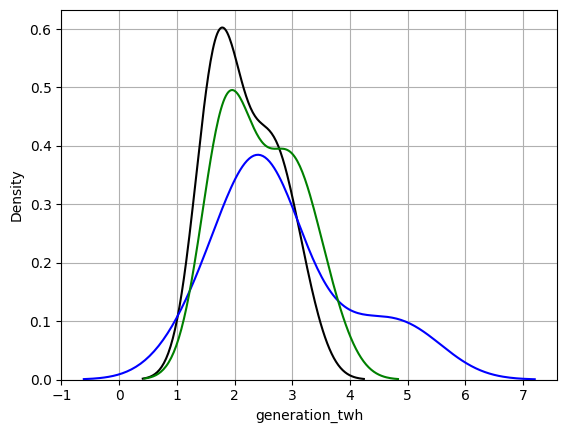

In [24]:
sns.kdeplot(gas_power_generation_2025['generation_twh'], color="black")
sns.kdeplot(gas_power_generation_2024['generation_twh'], color = "blue")
sns.kdeplot(gas_power_generation_2023['generation_twh'], color= "green")
plt.grid()

In [ ]:
def file_upload(file_name):
    conn_string = "DefaultEndpointsProtocol=https;AccountName=indiapowerdata;AccountKey=Ngjt3Jhf8cTrB/OUXVIYP2tCdfhRqmhkZSKKMxyqVuddOKb+TOQ9kqpk5qri/WyprdcUoMiUgphh+AStUgpfSQ==;EndpointSuffix=core.windows.net"
    blb_service_client = BlobServiceClient.from_connection_string(conn_string)
    container_client_obj = blb_service_client.get_container_client("yearly-power-generation")
    with open(file = os.path.join("E:\\India-Power-Capacity-DE",file_name), mode="rb") as data:
        container_client_obj.upload_blob(name=file_name, data=data, overwrite=False)

In [9]:
dates = power_source_df['date']
months = pd.DatetimeIndex(power_source_df['date']).month
date_df = pd.DataFrame(dates)
pd.DataFrame(date_df.insert(1, "months",months, allow_duplicates=False))
print(date_df)

           date  months
121  2023-01-01       1
131  2023-02-01       2
141  2023-03-01       3
151  2023-04-01       4
161  2023-05-01       5
171  2023-06-01       6
181  2023-07-01       7
191  2023-08-01       8
201  2023-09-01       9
211  2023-10-01      10
221  2023-11-01      11
231  2023-12-01      12


In [10]:
print(
    power_df.groupby(
            [pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].mean())

date  series          
2022  Bioenergy             1.363333
      Coal                 97.061667
      Gas                   2.096667
      Hydro                14.547500
      Net imports          -0.162500
      Nuclear               3.850000
      Other fossil          0.016667
      Other renewables      0.208333
      Solar                 8.835000
      Wind                  5.837500
2023  Bioenergy             1.244167
      Coal                105.425833
      Gas                   2.450000
      Hydro                12.402500
      Net imports          -0.817500
      Nuclear               4.016667
      Other fossil          0.031667
      Other renewables      0.222500
      Solar                10.460000
      Wind                  6.841667
Name: generation_twh, dtype: float64


In [11]:
sorted_power_df = power_df.sort_values(by='generation_twh', ascending=False)

# print(sorted_power_df)

sorted_power_df.loc[sorted_power_df['series'] == 'Coal'].head(3)

,entity,entity_code,is_aggregate_entity,date,series,is_aggregate_series,generation_twh,share_of_generation_pct
211,India,IND,False,2023-10-01,Coal,False,114.00,76.05
151,India,IND,False,2023-04-01,Coal,False,109.10,77.22
31,India,IND,False,2022-04-01,Coal,False,108.91,76.30


In [12]:
sorted_power_df.groupby([pd.DatetimeIndex(sorted_power_df['date']).year, sorted_power_df['series']])['generation_twh'].sum()
# total_series_gen.max()

date  series          
2022  Bioenergy             16.36
      Coal                1164.74
      Gas                   25.16
      Hydro                174.57
      Net imports           -1.95
      Nuclear               46.20
      Other fossil           0.20
      Other renewables       2.50
      Solar                106.02
      Wind                  70.05
2023  Bioenergy             14.93
      Coal                1265.11
      Gas                   29.40
      Hydro                148.83
      Net imports           -9.81
      Nuclear               48.20
      Other fossil           0.38
      Other renewables       2.67
      Solar                125.52
      Wind                  82.10
Name: generation_twh, dtype: float64

In [ ]:
sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].mean()

series
Bioenergy             1.303750
Coal                101.243750
Gas                   2.273333
Hydro                13.475000
Net imports          -0.490000
Nuclear               3.933333
Other fossil          0.024167
Other renewables      0.215417
Solar                 9.647500
Wind                  6.339583
Name: generation_twh, dtype: float64

In [13]:
sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].max()

series
Bioenergy             2.59
Coal                114.00
Gas                   3.62
Hydro                24.93
Net imports           0.76
Nuclear               4.53
Other fossil          0.04
Other renewables      0.24
Solar                12.16
Wind                 12.45
Name: generation_twh, dtype: float64

In [14]:
sorted_power_df.groupby([sorted_power_df['series']])['generation_twh'].min()

series
Bioenergy            0.34
Coal                86.57
Gas                  1.59
Hydro                6.76
Net imports         -1.46
Nuclear              3.21
Other fossil         0.01
Other renewables     0.18
Solar                7.38
Wind                 2.49
Name: generation_twh, dtype: float64

In [19]:
sorted_power_df

,entity,entity_code,is_aggregate_entity,date,series,is_aggregate_series,generation_twh,share_of_generation_pct
211,India,IND,False,2023-10-01,Coal,False,114.00,76.05
151,India,IND,False,2023-04-01,Coal,False,109.10,77.22
31,India,IND,False,2022-04-01,Coal,False,108.91,76.30
161,India,IND,False,2023-05-01,Coal,False,108.65,73.12
141,India,IND,False,2023-03-01,Coal,False,106.46,76.84
...,...,...,...,...,...,...,...,...
134,India,IND,False,2023-02-01,Net imports,False,-1.03,-0.80
234,India,IND,False,2023-12-01,Net imports,False,-1.32,-0.99
144,India,IND,False,2023-03-01,Net imports,False,-1.33,-0.96
164,India,IND,False,2023-05-01,Net imports,False,-1.33,-0.90
